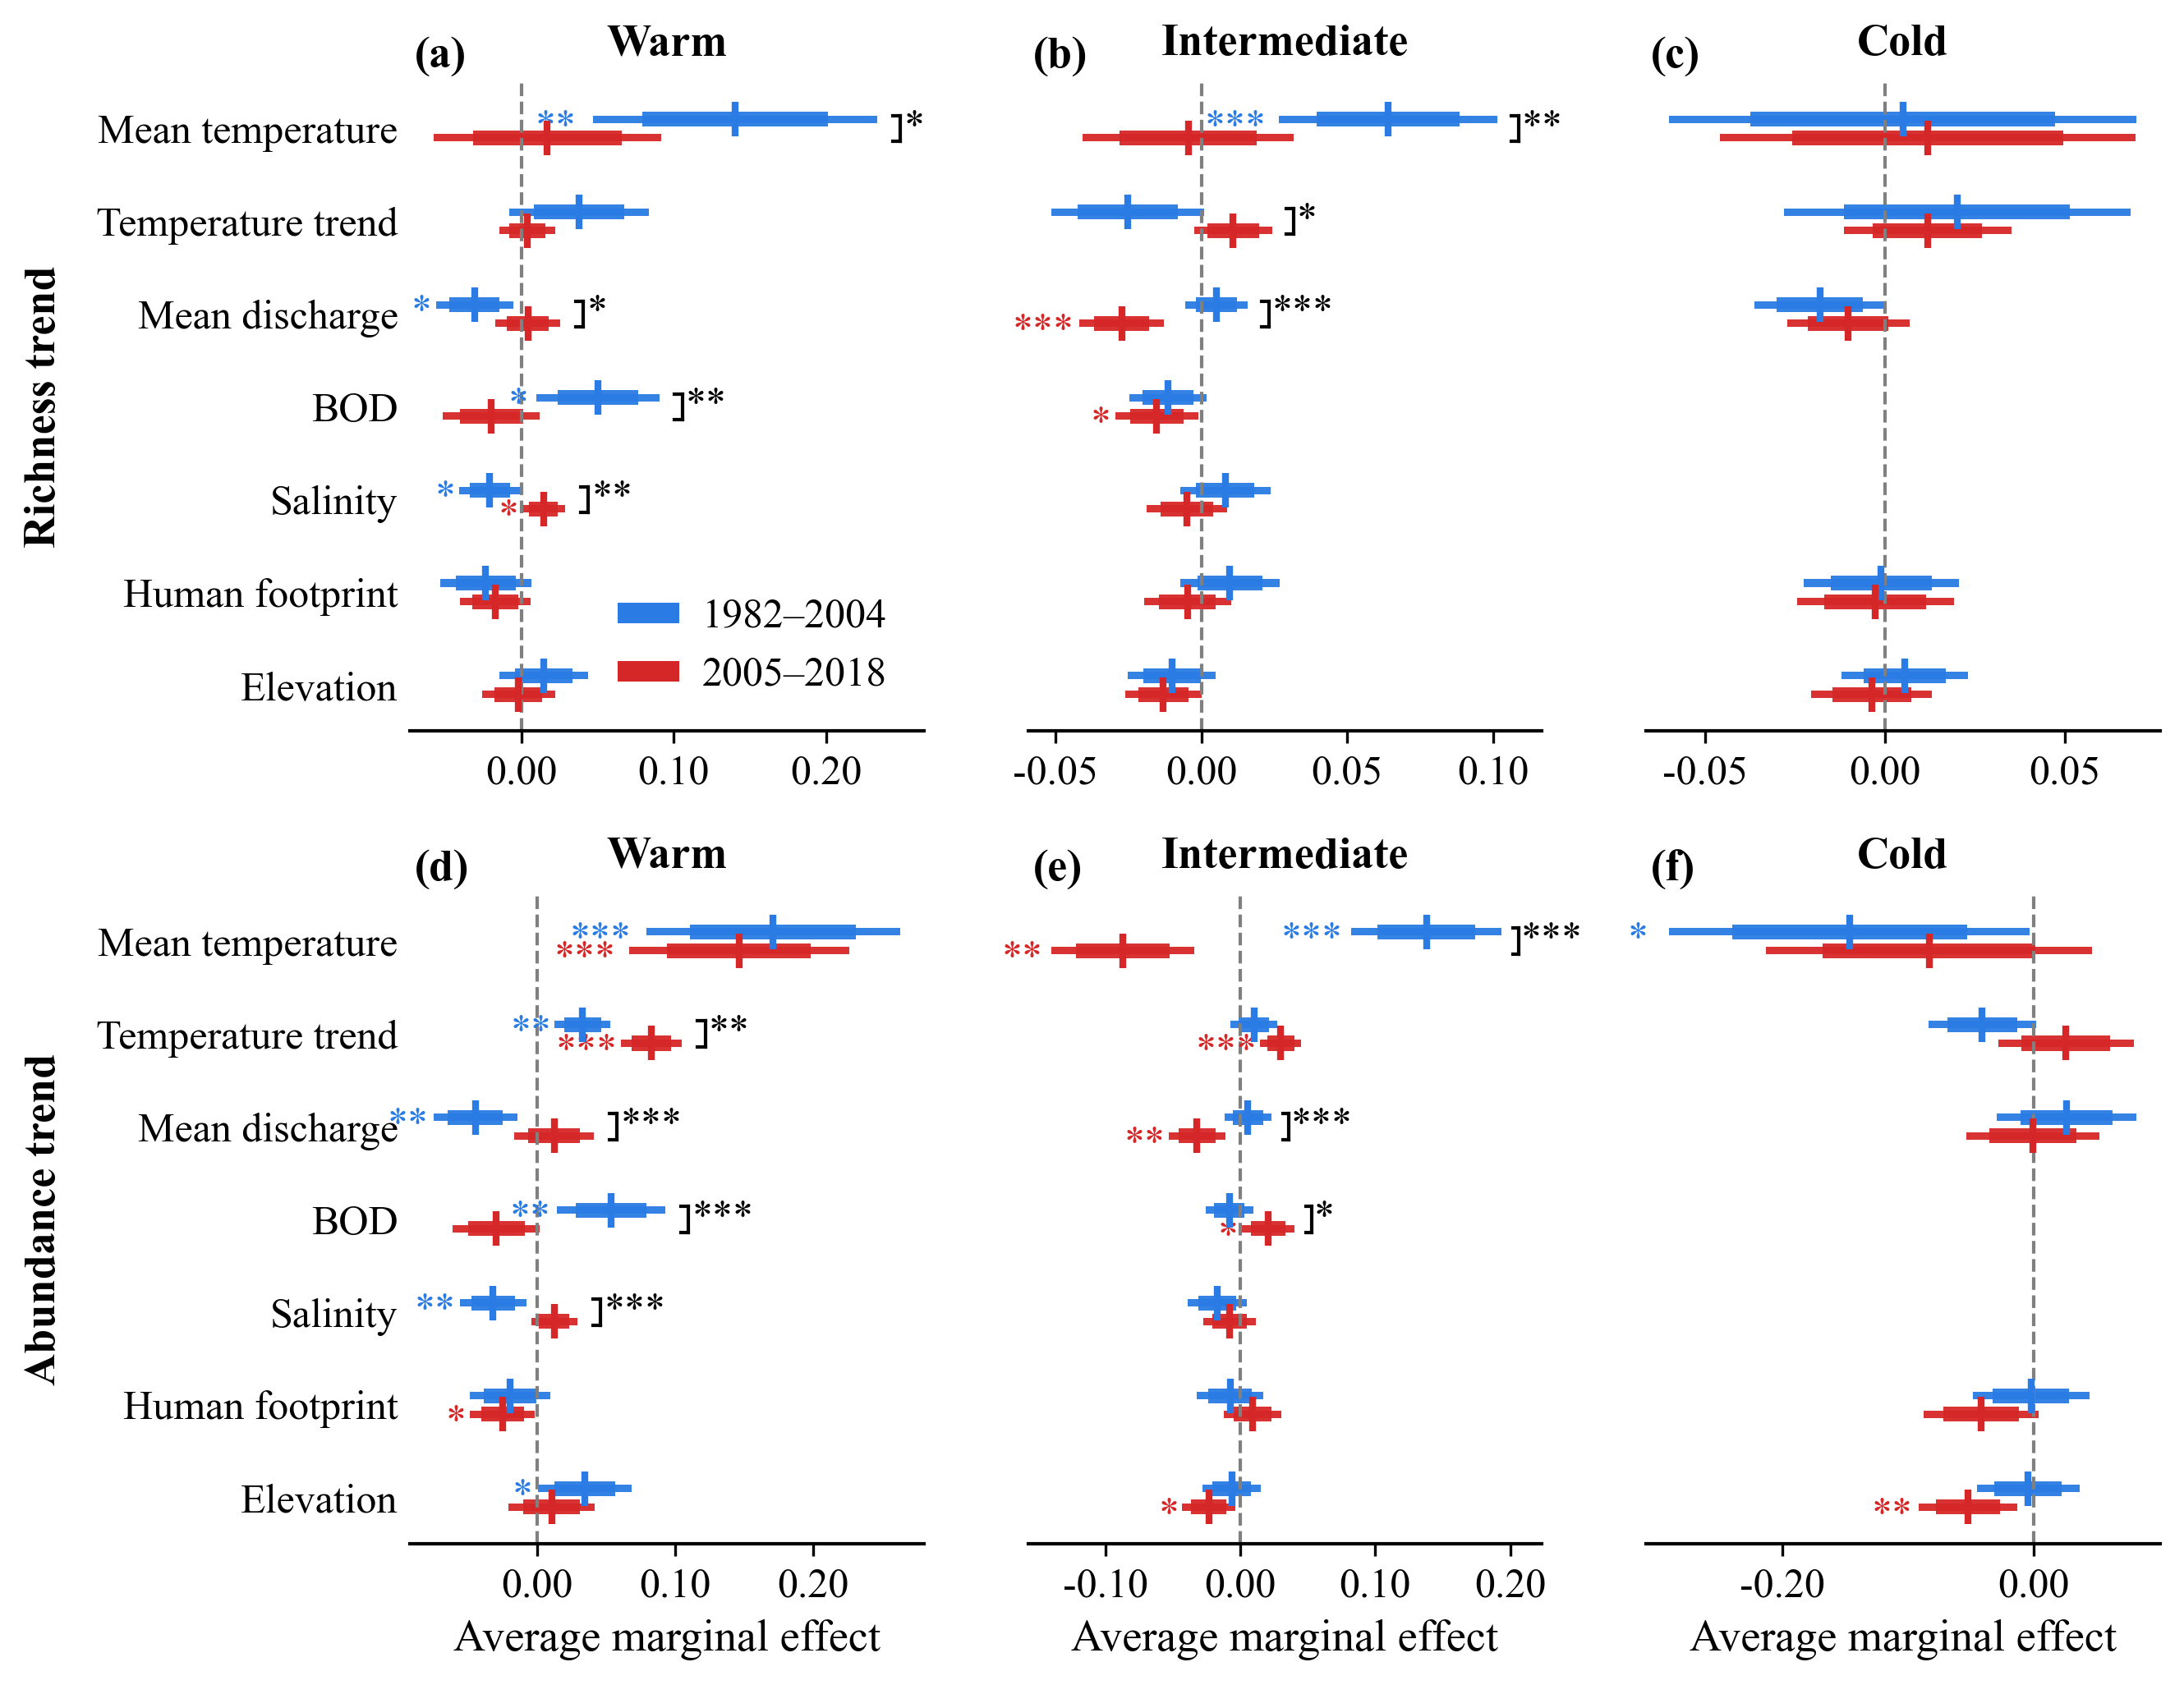

In [ ]:
# =========================================================
# Libraries
# =========================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

# =========================================================
# Read data
# =========================================================
df_rich = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of richness trends\Period_MarginalEffects_by_zone.csv"
)

df_abun = pd.read_csv(
    r"D:\paper\outputdata\Phase-specific modelling of abundance trends\Period_effects_by_zone_with_CI_Abundance_AME.csv"
)

# =========================================================
# Basic settings
# =========================================================
zones = ["Warm", "Intermediate", "Cold"]
panel_labels_top = ["(a)", "(b)", "(c)"]
panel_labels_bottom = ["(d)", "(e)", "(f)"]

plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "font.size": 12
})

EARLY_COLOR = "#2a7be4"
LATE_COLOR  = "#d62728"

W95 = 0.08
W80 = 0.16
Y_OFFSET = 0.10

Z95 = 1.96
Z80 = 1.28

order_vars = [
    "mean_temp",
    "sen_temp",
    "mean_Q",
    "mean_organic",
    "mean_salinity",
    "HFP_period",
    "elevation"
]

name_map = {
    "mean_temp":     "Mean temperature",
    "sen_temp":      "Temperature trend",
    "mean_Q":        "Mean discharge",
    "mean_organic":  "BOD",
    "mean_salinity": "Salinity",
    "HFP_period":    "Human footprint",
    "elevation":     "Elevation",
}

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def plot_period_effect_panel(ax, sub_z, lab, zone_title, show_ylabels=False, show_xlabel=True):
    vals = np.abs(sub_z[
        ["Early_CI95_L", "Early_CI95_U",
         "Late_CI95_L",  "Late_CI95_U"]
    ].values.flatten())

    M = max(np.round(vals.max() + 0.015, 2), 0.06)

    for i, v in enumerate(order_vars):
        y0 = i
        sub_v = sub_z[sub_z["Factor"] == v]
        if sub_v.empty:
            continue

        for eff, lo95, up95, dy, color, pval in [
            (
                sub_v["Early_Effect"].values[0],
                sub_v["Early_CI95_L"].values[0],
                sub_v["Early_CI95_U"].values[0],
                -Y_OFFSET,
                EARLY_COLOR,
                sub_v["Early_p"].values[0]
            ),
            (
                sub_v["Late_Effect"].values[0],
                sub_v["Late_CI95_L"].values[0],
                sub_v["Late_CI95_U"].values[0],
                +Y_OFFSET,
                LATE_COLOR,
                sub_v["Late_p"].values[0]
            )
        ]:
            yy = y0 + dy
            se = (up95 - eff) / Z95
            lo80 = eff - Z80 * se
            up80 = eff + Z80 * se

            # 95% CI
            ax.add_patch(Rectangle(
                (lo95, yy - W95/2),
                up95 - lo95,
                W95,
                facecolor=color,
                linewidth=0,
                alpha=0.95
            ))

            # 80% CI
            ax.add_patch(Rectangle(
                (lo80, yy - W80/2),
                up80 - lo80,
                W80,
                facecolor=color,
                linewidth=0,
                alpha=0.95
            ))

            # central effect
            ax.plot(
                eff, yy,
                marker="|",
                color=color,
                markersize=10,
                markeredgewidth=2,
                zorder=10
            )

            # significance star for each period
            star = p_to_star(pval)
            dx_star = 0.06 * (up95 - lo95)

            ax.text(
                lo95 - dx_star,
                yy + 0.1,
                star,
                color=color,
                fontsize=12,
                va="center",
                ha="right"
            )

        # delta significance
        p_delta = sub_v["Delta_p"].values[0]
        star_d = p_to_star(p_delta)

        if star_d:
            xmax = max(
                sub_v["Early_CI95_U"].values[0],
                sub_v["Late_CI95_U"].values[0]
            )

            dx = 0.03 * (2 * M)

            ax.plot(
                [xmax + dx, xmax + dx],
                [y0 - Y_OFFSET - W95/2, y0 + Y_OFFSET + W95/2],
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 - Y_OFFSET - W95/2, y0 - Y_OFFSET - W95/2],
                color="black", lw=1
            )
            ax.plot(
                [xmax + dx - 0.01*(2*M), xmax + dx],
                [y0 + Y_OFFSET + W95/2, y0 + Y_OFFSET + W95/2],
                color="black", lw=1
            )

            ax.text(
                xmax + dx * 1.15,
                y0,
                star_d,
                va="center",
                ha="left",
                fontsize=12
            )

    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    ax.text(
        0.01, 1.07, lab,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax.set_title(zone_title, fontsize=13, fontweight="bold", pad=8)
    if show_xlabel:
        ax.set_xlabel("Average marginal effect", fontsize=13)
    else:
        ax.set_xlabel("")

    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=12)
    ax.tick_params(axis="x", labelsize=12)

    ax.set_yticks(np.arange(len(order_vars)))
    if show_ylabels:
        ax.set_yticklabels([name_map[v] for v in order_vars], fontsize=12)
    else:
        ax.set_yticklabels([])

# =========================================================
# Create figure
# =========================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(9, 7),
    dpi=300,
    sharey='row'
)

# =========================================================
# Top row: Richness (a-c)
# =========================================================
for ax, z, lab in zip(axes[0], zones, panel_labels_top):
    sub_z = df_rich[df_rich["Zone"] == z]
    plot_period_effect_panel(
        ax=ax,
        sub_z=sub_z,
        lab=lab,
        zone_title=z,
        show_ylabels=(ax is axes[0, 0]),
        show_xlabel=False
    )

# =========================================================
# Bottom row: Abundance (d-f)
# =========================================================
for ax, z, lab in zip(axes[1], zones, panel_labels_bottom):
    sub_z = df_abun[df_abun["Zone"] == z]
    plot_period_effect_panel(
        ax=ax,
        sub_z=sub_z,
        lab=lab,
        zone_title=z,
        show_ylabels=(ax is axes[1, 0])
    )

# invert y-axis for first column in each row
axes[0, 0].invert_yaxis()
axes[1, 0].invert_yaxis()

# =========================================================
# Optional row labels
# =========================================================
axes[0, 0].text(
    -0.75, 0.5, "Richness trend",
    transform=axes[0, 0].transAxes,
    fontsize=13,
    fontweight="bold",
    rotation=90,
    ha="left", va="center"
)

axes[1, 0].text(
    -0.75, 0.5, "Abundance trend",
    transform=axes[1, 0].transAxes,
    fontsize=13,
    fontweight="bold",
    rotation=90,
    ha="left", va="center"
)

# =========================================================
# Legend
# =========================================================
legend_elems = [
    Line2D([0], [0], color=EARLY_COLOR, lw=6, label="1982–2004"),
    Line2D([0], [0], color=LATE_COLOR,  lw=6, label="2005–2018"),
]

axes[0, 0].legend(
    handles=legend_elems,
    loc="lower right",
    frameon=False,
    fontsize=12,
    handlelength=1
)

# restore left y labels
axes[0,0].set_yticklabels([name_map[v] for v in order_vars], fontsize=12)
axes[1,0].set_yticklabels([name_map[v] for v in order_vars], fontsize=12)

# =========================================================
# Layout and save
# =========================================================
plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\4.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()